In [13]:
# ==============================================================================
# ΜΗΝΑΣ 5: ADAPTIVE ST-GNN (GRAPH WAVENET / GTS APPROACH)
# ==============================================================================

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error, mean_absolute_error
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

# 1. Φόρτωση Yahoo Finance (Το Βασικό μας Dataset)
df_yahoo = pd.read_csv('crypto_log_returns_yahoo.csv', index_col='Date', parse_dates=True).fillna(0)
coins = df_yahoo.columns
num_nodes = len(coins)
volatility_data = np.abs(df_yahoo.values)

# 2. Scaling (0-1)
scaler = MinMaxScaler()
vol_scaled = scaler.fit_transform(volatility_data)

# 3. Δημιουργία Sequences (14 μέρες πίσω -> 1 μέρα μπροστά)
SEQ_LENGTH = 14
def create_sequences(data, seq_len):
    xs, ys = [], []
    for i in range(len(data) - seq_len):
        xs.append(data[i : i + seq_len])
        ys.append(data[i + seq_len])
    return np.array(xs), np.array(ys)

X, y = create_sequences(vol_scaled, SEQ_LENGTH)
X = np.expand_dims(X, axis=-1) # [Batch, Time, Nodes, 1]

split_idx = int(len(X) * 0.8)
X_train, X_test = torch.FloatTensor(X[:split_idx]), torch.FloatTensor(X[split_idx:])
y_train, y_test = torch.FloatTensor(y[:split_idx]), torch.FloatTensor(y[split_idx:])

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=False)

print(f"Δεδομένα Έτοιμα | X_train: {X_train.shape} | Κόμβοι (Νομίσματα): {num_nodes}")

Δεδομένα Έτοιμα | X_train: torch.Size([2377, 14, 10, 1]) | Κόμβοι (Νομίσματα): 10


In [14]:
# ==============================================================================
# ΟΡΙΣΜΟΣ ADAPTIVE ST-GNN
# ==============================================================================

class AdaptiveGraphConv(nn.Module):
    def __init__(self, num_nodes, node_dim, in_channels, out_channels):
        super(AdaptiveGraphConv, self).__init__()
        # Node Embeddings
        self.node_emb1 = nn.Parameter(torch.randn(num_nodes, node_dim))
        self.node_emb2 = nn.Parameter(torch.randn(node_dim, num_nodes))
        self.weight = nn.Parameter(torch.randn(in_channels, out_channels))
        
    def forward(self, x):
        # Δημιουργία του δυναμικού πίνακα γειτνίασης: A = ReLU(E1 * E2)
        learned_adj = F.relu(torch.matmul(self.node_emb1, self.node_emb2))
        
        # Κανονικοποίηση για να μην εκραγούν τα gradients (Softmax κατά γραμμές)
        learned_adj = F.softmax(learned_adj, dim=1)
        
        # Graph Convolution (AXW)
        out = torch.einsum('vw,btwc->btvc', learned_adj, x)
        out = torch.matmul(out, self.weight)
        return out, learned_adj

class AdaptiveSTGNN(nn.Module):
    def __init__(self, num_nodes, seq_len, in_channels=1, hidden_dim=32, node_dim=10):
        super(AdaptiveSTGNN, self).__init__()
        
        # 1. Temporal Convolution (TCN) για τον χρόνο
        self.tcn = nn.Conv2d(in_channels=1, out_channels=hidden_dim, kernel_size=(3, 1), padding=(1, 0))
        
        # 2. Adaptive Graph Convolution για τον χώρο
        self.gcn = AdaptiveGraphConv(num_nodes, node_dim, hidden_dim, hidden_dim)
        
        # 3. GRU για να δέσει τις χωροχρονικές πληροφορίες
        self.gru = nn.GRU(hidden_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # x shape: [Batch, Time, Nodes, 1]
        batch_size, seq_len, nodes, _ = x.shape
        
        # TCN (Το PyTorch Conv2d θέλει [Batch, Channels, Time, Nodes])
        x_tcn = x.permute(0, 3, 1, 2)
        h_tcn = F.relu(self.tcn(x_tcn))
        h_tcn = h_tcn.permute(0, 2, 3, 1) # Πίσω σε [Batch, Time, Nodes, Hidden]
        
        # Adaptive Graph Conv
        h_gcn, learned_adj = self.gcn(h_tcn)
        h_gcn = F.relu(h_gcn)
        
        # GRU
        gru_in = h_gcn.permute(0, 2, 1, 3).reshape(batch_size * nodes, seq_len, -1)
        gru_out, _ = self.gru(gru_in)
        last_out = gru_out[:, -1, :] 
        
        out = self.fc(last_out).reshape(batch_size, nodes)
        
        return F.softplus(out), learned_adj

model_st = AdaptiveSTGNN(num_nodes=num_nodes, seq_len=SEQ_LENGTH)
print("Adaptive ST-GNN Architecture Φορτώθηκε!")

Adaptive ST-GNN Architecture Φορτώθηκε!


--- Εκπαίδευση Adaptive ST-GNN ---
Epoch 10/100 | Training Loss: 0.004912
Epoch 20/100 | Training Loss: 0.004832
Epoch 30/100 | Training Loss: 0.004736
Epoch 40/100 | Training Loss: 0.004731
Epoch 50/100 | Training Loss: 0.004718
Epoch 60/100 | Training Loss: 0.004713
Epoch 70/100 | Training Loss: 0.004697
Epoch 80/100 | Training Loss: 0.004673
Epoch 90/100 | Training Loss: 0.004291
Epoch 100/100 | Training Loss: 0.004248


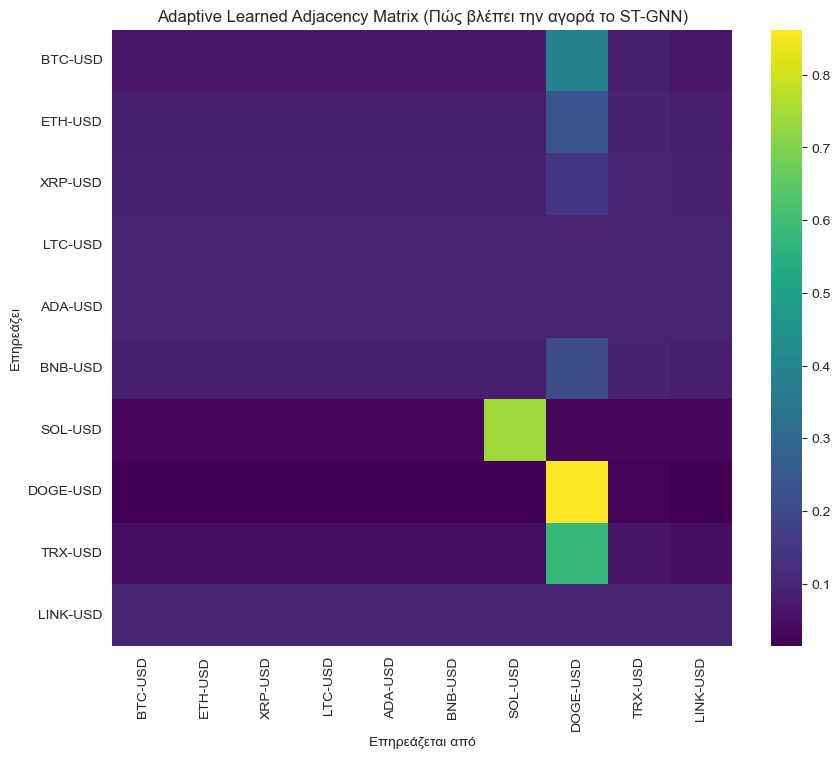

In [15]:
# ==============================================================================
# ΕΚΠΑΙΔΕΥΣΗ & ΕΞΑΓΩΓΗ ΤΟΥ ΜΑΘΗΜΕΝΟΥ ΓΡΑΦΟΥ
# ==============================================================================

optimizer = torch.optim.Adam(model_st.parameters(), lr=0.005, weight_decay=1e-5)
criterion = nn.MSELoss()

epochs = 100
best_loss = float('inf')
patience = 15
patience_counter = 0

print("--- Εκπαίδευση Adaptive ST-GNN ---")
for epoch in range(epochs):
    model_st.train()
    total_loss = 0
    for b_x, b_y in train_loader:
        optimizer.zero_grad()
        out, _ = model_st(b_x)
        loss = criterion(out, b_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        
    val_loss = total_loss / len(train_loader)
    
    if val_loss < best_loss:
        best_loss = val_loss
        patience_counter = 0
        # Αποθήκευση του καλύτερου δυναμικού γράφου
        _, best_adj = model_st(X_test) 
    else:
        patience_counter += 1
        
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Training Loss: {val_loss:.6f}")
        
    if patience_counter >= patience:
        print(f"Early stopping στην Εποχή {epoch+1}.")
        break

# Οπτικοποίηση του Γράφου που έμαθε το μοντέλο
adj_matrix_np = best_adj.cpu().detach().numpy()

plt.figure(figsize=(10, 8))
sns.heatmap(adj_matrix_np, xticklabels=coins, yticklabels=coins, cmap='viridis', annot=False)
plt.title("Adaptive Learned Adjacency Matrix (Πώς βλέπει την αγορά το ST-GNN)")
plt.xlabel("Επηρεάζεται από")
plt.ylabel("Επηρεάζει")
plt.show()

In [16]:
# ==============================================================================
# ΑΞΙΟΛΟΓΗΣΗ ΚΑΙ ΣΤΑΤΙΣΤΙΚΗ ΣΗΜΑΝΤΙΚΟΤΗΤΑ (DIEBOLD-MARIANO)
# ==============================================================================

model_st.eval()
with torch.no_grad():
    y_pred, _ = model_st(X_test)
    
# Inverse transform μόνο για το Node 0 (BTC)
y_pred_btc = scaler.inverse_transform(y_pred.numpy())[:, 0] * 100
y_true_btc = scaler.inverse_transform(y_test.numpy())[:, 0] * 100
y_pred_btc = np.clip(y_pred_btc, 0.1, None)

# Metrics
rmse_st = np.sqrt(mean_squared_error(y_true_btc, y_pred_btc))
mae_st = mean_absolute_error(y_true_btc, y_pred_btc)
qlike_st = np.mean(np.log(y_pred_btc**2) + (y_true_btc**2 / y_pred_btc**2))

print("=== FINAL ADAPTIVE ST-GNN METRICS (BTC) ===")
print(f"RMSE:  {rmse_st:.4f}")
print(f"MAE:   {mae_st:.4f}")
print(f"QLIKE: {qlike_st:.4f}")

# --- Diebold-Mariano Test ---
# Συγκρίνουμε το ST-GNN με το Naive Baseline (η αυριανή μεταβλητότητα = σημερινή)
naive_pred = np.roll(y_true_btc, shift=1)
naive_pred[0] = naive_pred[1]

# Υπολογισμός Differential (d) βάσει του RMSE
L1 = (y_true_btc - naive_pred)**2
L2 = (y_true_btc - y_pred_btc)**2
d = L1 - L2

dm_stat = np.mean(d) / np.sqrt(np.var(d, ddof=1) / len(d))
p_value = 2 * (1 - stats.norm.cdf(abs(dm_stat)))

print("\n=== DIEBOLD-MARIANO TEST (ST-GNN vs Naive) ===")
print(f"DM Statistic: {dm_stat:.4f} | p-value: {p_value:.4e}")
if p_value < 0.05 and dm_stat > 0:
    print("-> ΣΥΜΠΕΡΑΣΜΑ: Το Adaptive ST-GNN είναι ΣΤΑΤΙΣΤΙΚΑ ΣΗΜΑΝΤΙΚΑ ΚΑΛΥΤΕΡΟ!")

=== FINAL ADAPTIVE ST-GNN METRICS (BTC) ===
RMSE:  1.7645
MAE:   1.2678
QLIKE: 3.0163

=== DIEBOLD-MARIANO TEST (ST-GNN vs Naive) ===
DM Statistic: 5.5776 | p-value: 2.4379e-08
-> ΣΥΜΠΕΡΑΣΜΑ: Το Adaptive ST-GNN είναι ΣΤΑΤΙΣΤΙΚΑ ΣΗΜΑΝΤΙΚΑ ΚΑΛΥΤΕΡΟ!


In [17]:
# ==============================================================================
# ΜΗΝΑΣ 5 (ROBUSTNESS CHECK): FROZEN ADAPTIVE GNN ΣΕ BINANCE ΚΑΙ COINBASE
# ==============================================================================

print("\n=== ROBUSTNESS CHECK ADAPTIVE ST-GNN (BINANCE & COINBASE) ===")

def prepare_and_eval_stgnn(filepath, source_name):
    df = pd.read_csv(filepath, index_col='Date', parse_dates=True).fillna(0)
    vol_scaled = scaler.transform(np.abs(df.values))
    X_ext, y_ext = create_sequences(vol_scaled, SEQ_LENGTH)
    X_tens = torch.FloatTensor(np.expand_dims(X_ext, axis=-1))
    y_tens = torch.FloatTensor(y_ext)
    
    model_st.eval()
    with torch.no_grad():
        y_pred, _ = model_st(X_tens)
        
    y_p_btc = scaler.inverse_transform(y_pred.numpy())[:, 0] * 100
    y_t_btc = scaler.inverse_transform(y_tens.numpy())[:, 0] * 100
    y_p_btc = np.clip(y_p_btc, 0.1, None)
    
    rmse = np.sqrt(mean_squared_error(y_t_btc, y_p_btc))
    qlike = np.mean(np.log(y_p_btc**2) + (y_t_btc**2 / y_p_btc**2))
    print(f"{source_name} | RMSE: {rmse:.4f} | QLIKE: {qlike:.4f}")

prepare_and_eval_stgnn('crypto_log_returns_binance.csv', "BINANCE")
prepare_and_eval_stgnn('crypto_log_returns_coinbase.csv', "COINBASE")


=== ROBUSTNESS CHECK ADAPTIVE ST-GNN (BINANCE & COINBASE) ===
BINANCE | RMSE: 1.7509 | QLIKE: 3.0202
COINBASE | RMSE: 1.6805 | QLIKE: 2.8494
